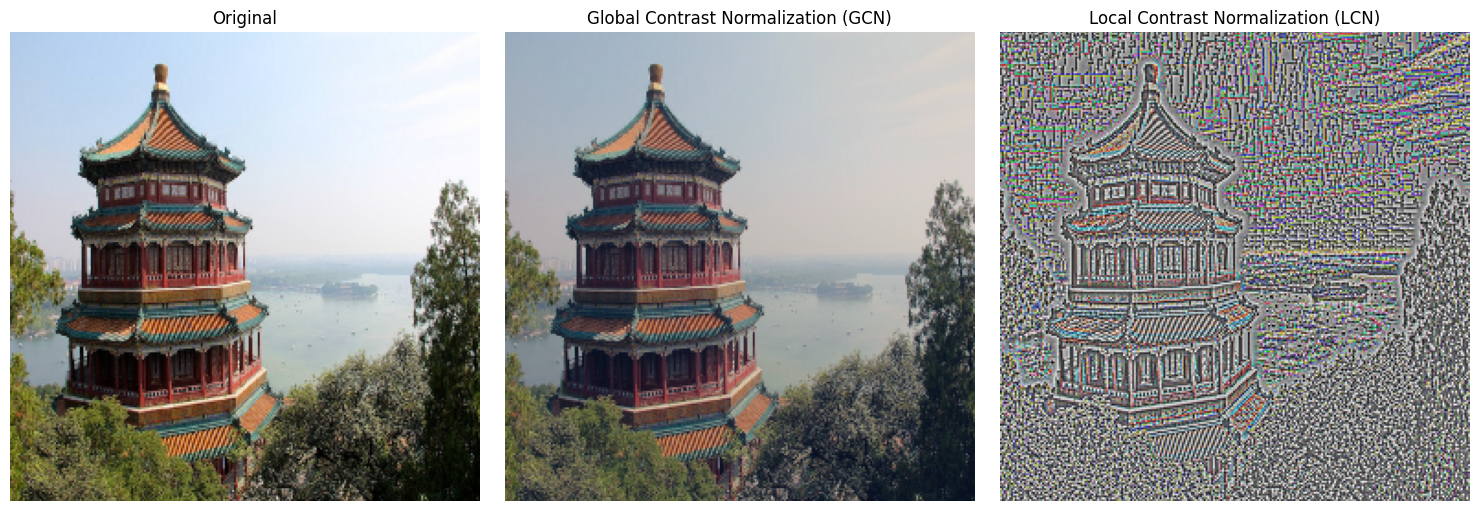

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.datasets import load_sample_image
import cv2

# ========== Global Contrast Normalization ==========
def gcn(image):
    image = image.astype(np.float32)
    mean = np.mean(image)
    std = np.std(image)
    normalized = (image - mean) / (std + 1e-8)
    return np.clip(normalized * 64 + 128, 0, 255).astype(np.uint8)

# ========== Local Contrast Normalization ==========
def lcn(image, sigma=1.0):
    image = image.astype(np.float32)
    local_mean = gaussian_filter(image, sigma=sigma)
    centered = image - local_mean
    local_var = gaussian_filter(centered**2, sigma=sigma)
    local_std = np.sqrt(local_var)
    normalized = centered / (local_std + 1e-8)
    return np.clip(normalized * 64 + 128, 0, 255).astype(np.uint8)

# ========== Load a sample image ==========
china = load_sample_image("china.jpg")  # Shape (427, 640, 3), RGB
image = cv2.resize(china, (256, 256))   # Resize for easier visualization

# ========== Apply GCN and LCN channel-wise ==========
gcn_image = np.stack([gcn(image[:, :, c]) for c in range(3)], axis=2)
lcn_image = np.stack([lcn(image[:, :, c]) for c in range(3)], axis=2)

# ========== Plot the results ==========
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Global Contrast Normalization (GCN)")
plt.imshow(gcn_image)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Local Contrast Normalization (LCN)")
plt.imshow(lcn_image)
plt.axis("off")

plt.tight_layout()
plt.show()

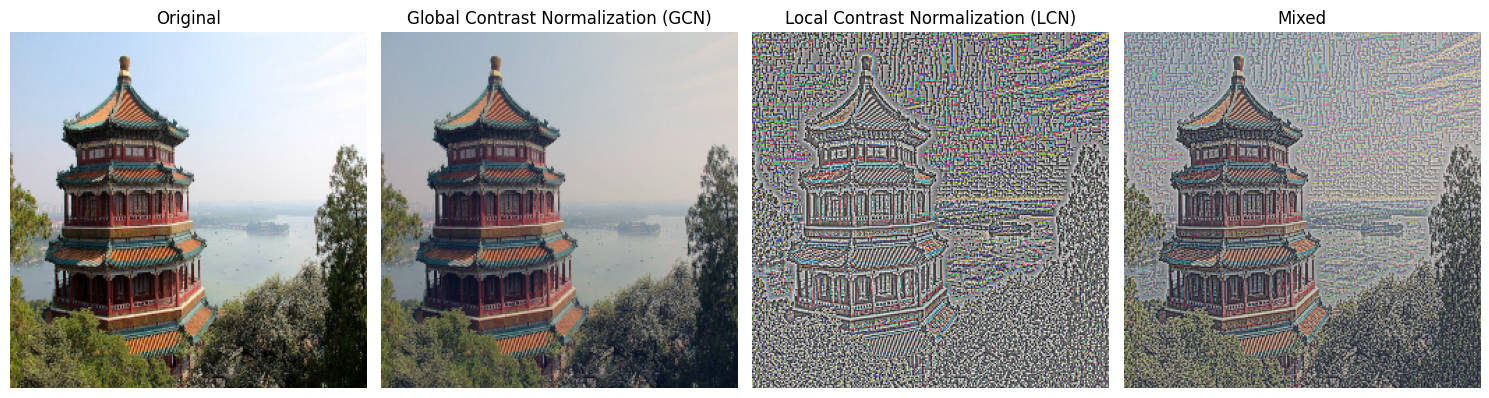

In [4]:
# prompt: take 50% from GCN and 50% from LCN and mix

# Mix GCN and LCN
mixed_image = (0.5 * gcn_image) + (0.5 * lcn_image)
mixed_image = mixed_image.astype(np.uint8)


# ========== Plot the results ==========
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Global Contrast Normalization (GCN)")
plt.imshow(gcn_image)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Local Contrast Normalization (LCN)")
plt.imshow(lcn_image)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Mixed")
plt.imshow(mixed_image)
plt.axis("off")

plt.tight_layout()
plt.show()
